In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [3]:
env = gym.make("FrozenLake-v1", is_slippery=True)

In [4]:
state_space = env.observation_space.n
action_space = env.action_space.n

print("States:", state_space)
print("Actions:", action_space)

States: 16
Actions: 4


In [5]:
Q = np.zeros((state_space, action_space))

In [7]:
alpha = 0.1          
gamma = 0.99         
epsilon = 1.0       
epsilon_decay = 0.995
min_epsilon = 0.01

episodes = 1000
max_steps = 100

In [8]:
rewards = []

for episode in range(episodes):
    state, _ = env.reset()
    total_reward = 0
    
    for step in range(max_steps):
        
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])
        
        next_state, reward, terminated, truncated, _ = env.step(action)
        
        Q[state, action] += alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )
        
        state = next_state
        total_reward += reward
        
        if terminated or truncated:
            break
    
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    rewards.append(total_reward)

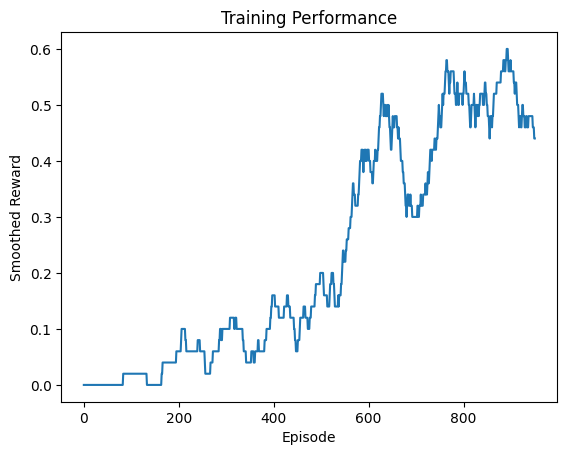

In [9]:
window = 50
rolling_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')

plt.plot(rolling_avg)
plt.xlabel("Episode")
plt.ylabel("Smoothed Reward")
plt.title("Training Performance")
plt.show()

In [10]:
def evaluate_random(env, episodes=100):
    total = 0
    for _ in range(episodes):
        state, _ = env.reset()
        done = False
        
        while not done:
            action = env.action_space.sample()
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total += reward
    
    return total / episodes

In [11]:
def evaluate_trained(env, Q, episodes=100):
    total = 0
    for _ in range(episodes):
        state, _ = env.reset()
        done = False
        
        while not done:
            action = np.argmax(Q[state])
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total += reward
    
    return total / episodes

In [12]:
print("Random policy average reward:", evaluate_random(env))
print("Trained policy average reward:", evaluate_trained(env, Q))

Random policy average reward: 0.02
Trained policy average reward: 0.41


REFLECTION


Reflection Part 1

Effect of Changing Learning Rate (α)

Learning rate controls how aggressively the Q-values update.

initally it is slow like 0.1 :

giving good results after 200 and after 600 episodes 


but if we n=make it agressively high which is around 0.5 and above:

Q-values changed very quickly.

Training looked unstable.

Reflection Part 2:

Most likely your reward curve stayed near zero for the first few hundred episodes.

Then around episode 200–400, performance started increasing.


At the beginning:


The agent mostly falls into holes.

Q-values remain near zero.


Eventually:

By random exploration, it reaches the goal.

That single reward of 1 updates the Q-value of the final state-action.